In [1]:
import torch
import torch.nn as nn
import os
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
from torch.optim import Adam
import matplotlib.pyplot as plt
import gc

torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [2]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [3]:
%cd /content/drive/MyDrive/CursoPINN-CEIA-UBA/20253B/Material didáctico/Modulo7

/content/drive/MyDrive/CursoPINN-CEIA-UBA/20253B/Material didáctico/Modulo7


In [4]:
def activation(name):
    if name in ['tanh', 'Tanh']:
        return nn.Tanh()
    elif name in ['relu', 'ReLU']:
        return nn.ReLU(inplace=True)
    elif name in ['lrelu', 'LReLU']:
        return nn.LeakyReLU(inplace=True)
    elif name in ['sigmoid', 'Sigmoid']:
        return nn.Sigmoid()
    elif name in ['softplus', 'Softplus']:
        return nn.Softplus(beta=4)
    elif name in ['celu', 'CeLU']:
        return nn.CELU()
    elif name in ['elu']:
        return nn.ELU()
    elif name in ['mish']:
        return nn.Mish()
    else:
        raise ValueError('Unknown activation function')


In [5]:
class SpectralConv1d(nn.Module):
    """
    1D Fourier convolution layer.
    Performs FFT → multiply low-frequency modes by learned complex weights → inverse FFT.
    """
    def __init__(self, in_channels, out_channels, num_modes):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.num_modes = num_modes  # Number of Fourier modes to keep

        # Learnable complex weights for the retained modes
        scale = 1 / (in_channels * out_channels)
        self.fourier_weights = nn.Parameter(
            scale * torch.rand(in_channels, out_channels, num_modes, dtype=torch.cfloat)
        )

    def complex_multiply(self, input_ft, weights):
        """
        input_ft:  (batch, in_channel, modes)
        weights:   (in_channel, out_channel, modes)
        returns:   (batch, out_channel, modes)
        """
        return torch.einsum("bix,iox->box", input_ft, weights)

    def forward(self, x):
        """
        x: (batch, in_channel, n_grid_points)
        """
        batch_size, _, n_grid = x.shape

        # FFT: real-to-complex transform
        x_ft = torch.fft.rfft(x)

        # Allocate output in Fourier space
        out_ft = torch.zeros(
            batch_size, self.out_channels, n_grid // 2 + 1,
            device=x.device, dtype=torch.cfloat
        )

        # Multiply low-frequency modes by learnable weights
        out_ft[:, :, :self.num_modes] = self.complex_multiply(
            x_ft[:, :, :self.num_modes], self.fourier_weights
        )

        # Inverse FFT: back to real space
        return torch.fft.irfft(out_ft, n=n_grid)

In [6]:
class FNO1d(nn.Module):
    """
    1D Fourier Neural Operator for time-stepping PDEs (e.g., Allen-Cahn equation).

    Structure:
    1. Lift input to higher channel dimension with a linear layer.
    2. Apply several Fourier layers (SpectralConv + pointwise Conv1d).
    3. Project back to output dimension.
    """
    def __init__(self, num_modes, width, num_fourier_layers=3):
        super().__init__()
        self.width = width
        self.num_modes = num_modes

        # Step 1: Input projection (2 → width)
        # Two input channels: initial condition u0(x) and coordinate x
        self.input_proj = nn.Linear(2, width)

        # Step 2: Fourier layers
        self.fourier_layers = nn.ModuleList()
        self.pointwise_layers = nn.ModuleList()
        for _ in range(num_fourier_layers):
            self.fourier_layers.append(SpectralConv1d(width, width, num_modes))
            self.pointwise_layers.append(nn.Conv1d(width, width, kernel_size=1)) #1x1 convolution (pointwise convolution)

        # Step 3: Output projection
        self.hidden_proj = nn.Linear(width, 32)
        self.output_proj = nn.Linear(32, 1)

        self.activation = nn.Tanh()

    def forward(self, x):
        """
        x: (batch, n_grid_points, 2)  -- 2 channels: (u0(x), x)
        returns: (batch, n_grid_points, 1)
        """
        # Lift input to width channels
        x = self.input_proj(x)                          # (B, N, width)
        x = x.permute(0, 2, 1)                          # (B, width, N) for Conv1d

        # Apply Fourier + pointwise conv layers
        for spectral_layer, pointwise_layer in zip(self.fourier_layers, self.pointwise_layers):
            x = spectral_layer(x) + pointwise_layer(x)  # Integral operator ≈ spectral + local term
            x = self.activation(x)

        # Project back to physical space
        x = x.permute(0, 2, 1)                          # (B, N, width)
        x = self.activation(self.hidden_proj(x))
        x = self.output_proj(x)                         # (B, N, 1)
        return x

In [7]:
# Load the data
x_data = torch.from_numpy(np.load("AC_data_input.npy")).type(torch.float32)
y_data = torch.from_numpy(np.load("AC_data_output.npy")).type(torch.float32)

print(f'x_data shape: {x_data.shape}')
print(f'y_data shape: {y_data.shape}')

x_data shape: torch.Size([1000, 1001, 2])
y_data shape: torch.Size([1000, 1001])


In [8]:
temporary_tensor = torch.clone(x_data[:, :, 0])
x_data[:, :, 0] = x_data[:, :, 1]
x_data[:, :, 1] = temporary_tensor

In [23]:
id_sample = np.random.randint(0, x_data.shape[0])
temporary_tensor[id_sample, :]

tensor([-1.0000, -0.9980, -0.9960,  ...,  0.9960,  0.9980,  1.0000])

In [24]:
n_train = 100 # number of training samples
input_function_train = x_data[:n_train, :]
output_function_train = y_data[:n_train, :]
input_function_test = x_data[n_train:, :]
output_function_test = y_data[n_train:, :]

In [25]:
batch_size = 10
training_set = DataLoader(TensorDataset(input_function_train, output_function_train), batch_size=batch_size, shuffle=True)
testing_set = DataLoader(TensorDataset(input_function_test, output_function_test), batch_size=batch_size, shuffle=False)

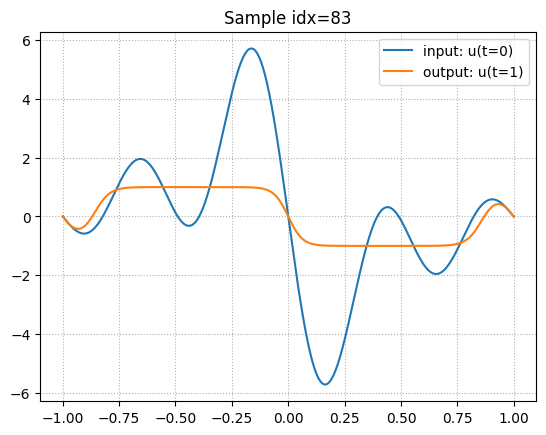

In [28]:
id_sample = np.random.randint(0, input_function_train.shape[0])
plt.figure()
plt.plot(input_function_train[id_sample, :, 1], input_function_train[id_sample, :, 0], label="input: u(t=0)")
plt.plot(input_function_train[id_sample, :, 1], output_function_train[id_sample, :], label="output: u(t=1)")
plt.grid(True, which="both", ls=":")
plt.title(f'Sample idx={id_sample}')
plt.legend()
plt.show()

In [29]:
modes = 16
width = 64
fno = FNO1d(modes, width) # model

In [35]:
learning_rate = 0.001
epochs = 100 # = 250
step_size = 50
gamma = 0.5

optimizer = Adam(fno.parameters(), lr=learning_rate, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=gamma)

In [49]:
output_batch

tensor([[ 0.0000,  0.0316,  0.0632,  ..., -0.0632, -0.0316,  0.0000],
        [ 0.0000,  0.0199,  0.0397,  ..., -0.0397, -0.0199,  0.0000],
        [ 0.0000,  0.0313,  0.0626,  ..., -0.0626, -0.0313,  0.0000],
        ...,
        [ 0.0000,  0.0316,  0.0631,  ..., -0.0631, -0.0316,  0.0000],
        [ 0.0000,  0.0292,  0.0583,  ..., -0.0583, -0.0292,  0.0000],
        [ 0.0000,  0.0282,  0.0563,  ..., -0.0563, -0.0282,  0.0000]])

In [47]:
l = torch.nn.MSELoss()
freq_print = 1
for epoch in range(epochs):
    train_mse = 0.0
    for step, (input_batch, output_batch) in enumerate(training_set):
        optimizer.zero_grad()
        output_pred_batch = fno(input_batch).squeeze(2)
        loss_f = l(output_pred_batch, output_batch)
        loss_f.backward()
        optimizer.step()
        train_mse += loss_f.item()
    train_mse /= len(training_set)

    scheduler.step()

    with torch.no_grad():
        fno.eval()
        test_relative_l2 = 0.0
        for step, (input_batch, output_batch) in enumerate(testing_set):
            output_pred_batch = fno(input_batch).squeeze(2)
            loss_f = (torch.mean((output_pred_batch - output_batch) ** 2) / torch.mean(output_batch ** 2)) ** 0.5 * 100
            test_relative_l2 += loss_f.item()
        test_relative_l2 /= len(testing_set)

    if epoch % freq_print == 0:
        print(f"######### Epoch: {epoch}, ######### Train Loss: {train_mse:.5f}, ######### Relative L2 Test Norm: {test_relative_l2:.5f}")

######### Epoch: 0, ######### Train Loss: 0.00135, ######### Relative L2 Test Norm: 4.69649


KeyboardInterrupt: 

In [43]:
idx_data = np.random.randint(0, input_function_test.shape[0])
input_function_test_n = input_function_test[idx_data, :].unsqueeze(0)
output_function_test_n = output_function_test[idx_data, :].unsqueeze(0)
print(f'input_function_test_n shape: {input_function_test_n.shape}')
print(f'output_function_test_n shape: {output_function_test_n.shape}')

input_function_test_n shape: torch.Size([1, 1001, 2])
output_function_test_n shape: torch.Size([1, 1001])


In [44]:
output_function_test_pred_n = fno(input_function_test_n)
print(f'output_function_test_pred_n shape: {output_function_test_pred_n.shape}')
print(f'output_function_test_n shape: {output_function_test_n.shape}')

output_function_test_pred_n shape: torch.Size([1, 1001, 1])
output_function_test_n shape: torch.Size([1, 1001])


Relative L2 error:  5.217206954956055


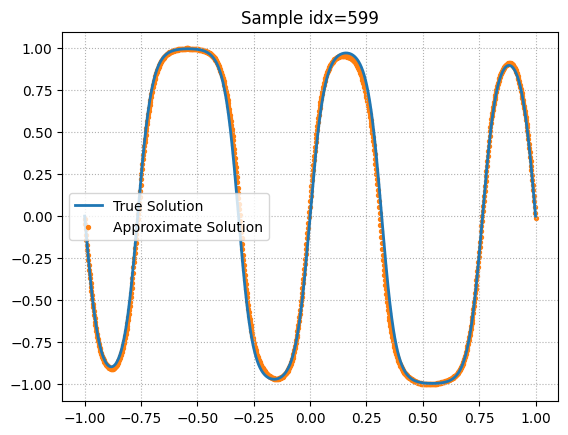

In [46]:
plt.figure()
plt.grid(True, which="both", ls=":")
plt.plot(input_function_test_n[0,:,1].detach(), output_function_test_n[0].detach(), label="True Solution", c="C0", lw=2)
plt.scatter(input_function_test_n[0,:,1].detach(), output_function_test_pred_n[0].detach(), label="Approximate Solution", s=8, c="C1")
p = 2
err = (torch.mean(abs(output_function_test_n.detach().reshape(-1, ) - output_function_test_pred_n.detach().reshape(-1, )) ** p) / torch.mean(abs(output_function_test_n.detach()) ** p)) ** (1 / p) * 100
print("Relative L2 error: ", err.item())
plt.title(f'Sample idx={idx_data}')
plt.legend()
plt.show()

In [71]:
n_train = 800  # adjust to your dataset size
n_test = x_data.shape[0] - n_train

# --- Swap channels if needed ---
x_data[:, :, [0,1]] = x_data[:, :, [1,0]]

# --- Training / testing split ---
input_train = x_data[:n_train]
output_train = y_data[:n_train]
input_test = x_data[n_train:]
output_test = y_data[n_train:]

# --- Hyperparameters ---
batch_size = 10
epochs = 10
learning_rate = 1e-3
modes = 16
width = 64

# --- Create model ---
fno = FNO1d(modes, width)
optimizer = Adam(fno.parameters(), lr=learning_rate, weight_decay=1e-5)
loss_fn = torch.nn.MSELoss()

# --- Grid sizes for multi-resolution training ---
train_grid_sizes = [64, 96, 128]  # choose arbitrary resolutions for demo

# --- Helper: interpolate batch to target grid ---
def interpolate_batch(u_batch, N_target):
    """
    u_batch: (B, N_coarse) or (B, N_coarse, 2)
    returns: (B, N_target) or (B, N_target, 2)
    """
    if u_batch.ndim == 2:
        u_batch = u_batch.unsqueeze(1)  # (B,1,N)
    else:
        u_batch = u_batch.permute(0,2,1)  # (B,2,N)
    u_interp = F.interpolate(u_batch, size=N_target, mode='linear', align_corners=True)
    if u_batch.ndim == 3 and u_batch.shape[1] == 2:
        u_interp = u_interp.permute(0,2,1)  # back to (B,N,2)
    else:
        u_interp = u_interp.squeeze(1)
    return u_interp

# --- Training loop ---
for epoch in range(epochs):
    fno.train()
    train_mse = 0.0

    # Shuffle indices for each epoch
    perm = torch.randperm(input_train.shape[0])
    for i in range(0, n_train, batch_size):
        idx = perm[i:i+batch_size]
        batch_input = input_train[idx]
        batch_output = output_train[idx]

        # --- Randomly choose a grid size for this batch ---
        N_target = np.random.choice(train_grid_sizes)

        # Interpolate input and output to the target grid
        batch_input_interp = interpolate_batch(batch_input, N_target)
        batch_output_interp = interpolate_batch(batch_output, N_target)

        # --- Forward / backward ---
        optimizer.zero_grad()
        pred = fno(batch_input_interp).squeeze(2)  # (B, N_target)
        loss = loss_fn(pred, batch_output_interp)
        loss.backward()
        optimizer.step()

        train_mse += loss.item()
    train_mse /= len(range(0, n_train, batch_size))

    # --- Optional: evaluate on a fixed fine grid ---
    fno.eval()
    with torch.no_grad():
        N_test_grid = 256
        input_test_fine = interpolate_batch(input_test, N_test_grid)
        output_test_fine = interpolate_batch(output_test, N_test_grid)
        pred_test = fno(input_test_fine).squeeze(2)
        rel_l2 = (torch.mean((pred_test - output_test_fine)**2) /
                  torch.mean(output_test_fine**2))**0.5 * 100

    print(f"Epoch {epoch}: Train MSE={train_mse:.6f}, Relative L2 Test={rel_l2:.3f}%")

Epoch 0: Train MSE=0.050423, Relative L2 Test=11.385%
Epoch 1: Train MSE=0.006265, Relative L2 Test=6.381%
Epoch 2: Train MSE=0.003788, Relative L2 Test=9.714%


KeyboardInterrupt: 

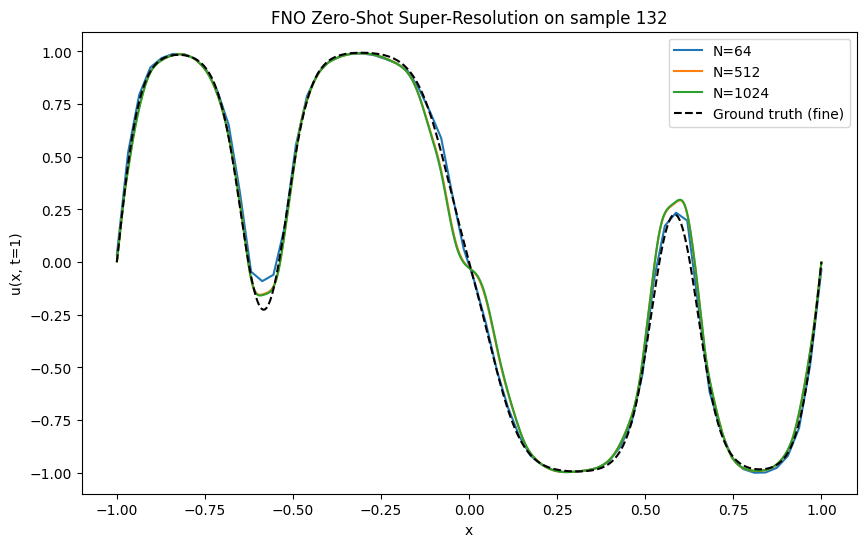

In [80]:
sample_idx = np.random.randint(0, input_test.shape[0])
u0 = input_test[sample_idx:sample_idx+1]  # (1, N_coarse, 2)
u_true = output_test[sample_idx:sample_idx+1]  # (1, N_coarse)

# --- Grid resolutions to test ---
test_grids = [64, 512, 1024]

plt.figure(figsize=(10,6))

for N in test_grids:
    # Interpolate input to current grid
    u0_interp = interpolate_batch(u0, N)

    # Run model
    fno.eval()
    with torch.no_grad():
        u_pred = fno(u0_interp).squeeze(0).squeeze(1)  # (N,)

    # Spatial coordinates
    x_coords = torch.linspace(-1, 1, N)

    # Plot prediction
    plt.plot(x_coords, u_pred.cpu(), label=f'N={N}')

# Optional: plot original fine-grid solution for reference
x_fine = torch.linspace(-1, 1, u_true.shape[1])
plt.plot(x_fine, u_true.squeeze(0).cpu(), 'k--', label='Ground truth (fine)')

plt.xlabel('x')
plt.ylabel('u(x, t=1)')
plt.title(f'FNO Zero-Shot Super-Resolution on sample {sample_idx}')
plt.legend()
plt.show()